# Proyecto - Implementación Fase 2
## Modelos DL
- Fabiola Contreras -22787
- María Villafuerte -22129

## Preparar el ambiente

In [4]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from torchvision import transforms

from cnn_model import (
    QRDataset, QRCNN, train_one_epoch, evaluate, SEED
)

In [5]:
#  Dispositivo
device = (
    torch.device("cuda")  if torch.cuda.is_available()
    else torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Dispositivo: {device}")

Dispositivo: cuda


In [6]:
# Datos
META_CSV = "data_procesada/qr_full_dataset.csv"

# Entrenamiento
EPOCHS   = 30
BATCH    = 64
LR       = 1e-3
DROPOUT  = 0.4
PATIENCE = 7

# Salida
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)


## Cargar datos

In [7]:
train_df = pd.read_csv("data_procesada/train.csv")
val_df   = pd.read_csv("data_procesada/val.csv")
test_df  = pd.read_csv("data_procesada/test.csv")

train_paths = train_df["filepath"].tolist()
train_labels = train_df["label"].tolist()

val_paths = val_df["filepath"].tolist()
val_labels = val_df["label"].tolist()

test_paths = test_df["filepath"].tolist()
test_labels = test_df["label"].tolist()

print(len(train_paths), len(val_paths), len(test_paths))

140000 30000 30000


In [8]:
aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
])

ds_train = QRDataset(train_paths, train_labels, transform=aug)
ds_val   = QRDataset(val_paths, val_labels)
ds_test  = QRDataset(test_paths, test_labels)

print(f"Train: {len(ds_train)} | Val: {len(ds_val)} | Test: {len(ds_test)}")

Train: 140000 | Val: 30000 | Test: 30000


In [9]:
kw = dict(num_workers=4, pin_memory=(device.type == "cuda"))

train_loader = DataLoader(ds_train, batch_size=BATCH, shuffle=True,  **kw)
val_loader   = DataLoader(ds_val,   batch_size=BATCH, shuffle=False, **kw)
test_loader  = DataLoader(ds_test,  batch_size=BATCH, shuffle=False, **kw)

## Modelo CNN

In [13]:
model = QRCNN(dropout=DROPOUT).to(device)

print(f"Parámetros: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Parámetros: 3142242


### Entrenamiento

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_loss = float("inf")
patience_cnt  = 0
history       = []

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    vl_loss, vl_acc, vl_auc, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step()

    history.append({
        "epoch": epoch,
        "train_loss": tr_loss,
        "train_acc": tr_acc,
        "val_loss": vl_loss,
        "val_acc": vl_acc,
        "val_auc": vl_auc
    })

    print(epoch, tr_loss, vl_loss)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        patience_cnt = 0
        torch.save(model.state_dict(), OUT_DIR / "best_model.pt")
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stopping en época {epoch}")
            break

1 0.16751428915304797 0.12951908467213313


Training:   0%|          | 0/2188 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


2 0.0515563755363492 0.02320835354673521


Training:   0%|          | 0/2188 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


3 0.030588803193033007 0.016022321930919618


...

28 0.0003209259784442603 0.0006379589542421165


Training:   0%|          | 0/2188 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


29 0.00032728928005123966 0.0006688574807630937


Training:   0%|          | 0/2188 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
                                                                                      

30 0.0004504731735452434 0.0006763761915978359


### Evaluación

In [37]:
model.load_state_dict(torch.load(OUT_DIR / "best_model.pt", map_location=device))

te_loss, te_acc, te_auc, preds, true, probs = evaluate(model, test_loader, criterion, device)

Evaluating:   0%|          | 0/469 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [43]:
print(f"Test Loss: {te_loss}")
print(f"Test Acc: {te_acc}")
print(f"Test AUC: {te_auc}")

Test Loss: 0.0006943410682397802
Test Acc: 0.9998666666666667
Test AUC: 0.9999998444444445


In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc  = accuracy_score(true, preds)
prec = precision_score(true, preds)
rec  = recall_score(true, preds)
f1   = f1_score(true, preds)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9999
Precision: 0.9998
Recall   : 0.9999
F1 Score : 0.9999


In [44]:
print(classification_report(true, preds, target_names=["normal", "malware"]))

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00     15000
     malware       1.00      1.00      1.00     15000

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000



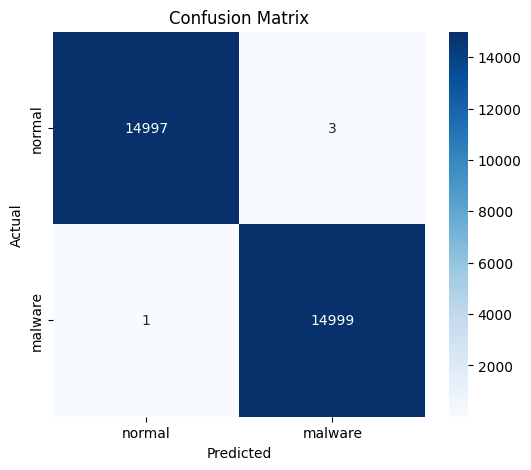

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["normal", "malware"],
            yticklabels=["normal", "malware"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

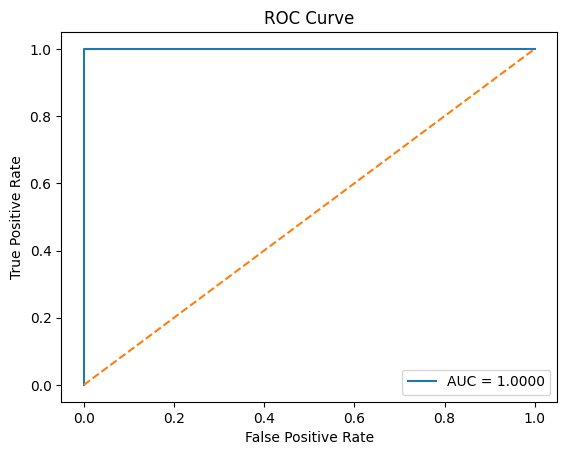

In [41]:
from sklearn.metrics import roc_curve, auc

# Asumiendo que tienes probabilidades en `probs`
fpr, tpr, _ = roc_curve(true, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Guardar resultados

In [ ]:
pd.DataFrame(history).to_csv(OUT_DIR / "training_cnn_history.csv", index=False)

with open(OUT_DIR / "test_metrics.json", "w") as f:
    json.dump({
        "test_loss": te_loss,
        "test_acc": te_acc,
        "test_auc": te_auc
    }, f, indent=2)

print(f"Artefactos guardados en {OUT_DIR}")

In [ ]:
df_preds = pd.DataFrame({
    "true": true,
    "pred": preds,
    "prob_malware": probs
})

df_preds.to_csv(OUT_DIR / "test_predictions.csv", index=False)

## Modelo ViT (Vision Transformer)

### Configuración e instalación

In [2]:
# timm ya viene instalado en Colab; si no: 
import timm
print(f"timm version: {timm.__version__}")

timm version: 1.0.26


In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


In [15]:
LR_VIT        = 1e-4   # LR menor para fine-tuning de pesos preentrenados
EPOCHS_VIT    = 30
FREEZE_LAYERS = 6      # congelar primeros 6 bloques transformer

vit_model = timm.create_model(
    'vit_tiny_patch16_224',
    pretrained=True,
    in_chans=1,
    num_classes=2,
    img_size=128,   # 128/16=8 → 8×8=64 patches
)
vit_model = vit_model.to(device)

for block in list(vit_model.blocks.children())[:FREEZE_LAYERS]:
    for param in block.parameters():
        param.requires_grad = False

total_params     = sum(p.numel() for p in vit_model.parameters())
trainable_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f"Parámetros totales    : {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")

Parámetros totales    : 5,401,154
Parámetros entrenables: 2,731,970


### Entrenamiento

In [16]:
optimizer_vit = optim.AdamW(
    filter(lambda p: p.requires_grad, vit_model.parameters()),
    lr=LR_VIT, weight_decay=1e-4
)
scheduler_vit = optim.lr_scheduler.CosineAnnealingLR(optimizer_vit, T_max=EPOCHS_VIT)

best_val_loss_vit = float("inf")
patience_cnt_vit  = 0
history_vit       = []

for epoch in range(1, EPOCHS_VIT + 1):
    tr_loss, tr_acc = train_one_epoch(
        vit_model, train_loader, criterion, optimizer_vit, device
    )
    vl_loss, vl_acc, vl_auc, _, _ = evaluate(
        vit_model, val_loader, criterion, device
    )
    scheduler_vit.step()

    history_vit.append({
        "epoch": epoch, "train_loss": tr_loss,
        "train_acc": tr_acc, "val_loss": vl_loss,
        "val_acc": vl_acc, "val_auc": vl_auc
    })
    print(epoch, tr_loss, vl_loss)

    if vl_loss < best_val_loss_vit:
        best_val_loss_vit = vl_loss
        patience_cnt_vit  = 0
        torch.save(vit_model.state_dict(), OUT_DIR / "best_vit_model.pt")
    else:
        patience_cnt_vit += 1
        if patience_cnt_vit >= PATIENCE:
            print(f"Early stopping en época {epoch}")
            break

FileNotFoundError: Caught FileNotFoundError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "c:\Users\villa\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\_utils\worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "c:\Users\villa\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\_utils\fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "c:\Users\villa\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\_utils\fetch.py", line 52, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "e:\Clases_S9\2.DataSecurity\malicious-qr-detector\cnn_model.py", line 36, in __getitem__
    img = Image.open(self.filepaths[idx]).convert("L").resize((IMG_SIZE, IMG_SIZE))
  File "c:\Users\villa\AppData\Local\Programs\Python\Python310\lib\site-packages\PIL\

### Evaluación

In [ ]:
vit_model.load_state_dict(torch.load(OUT_DIR / "best_vit_model.pt", map_location=device))

vit_loss, vit_acc, vit_auc, vit_preds, vit_true, vit_probs = evaluate(
    vit_model, test_loader, criterion, device
)

In [ ]:
print(f"Test Loss: {vit_loss}")
print(f"Test Acc : {vit_acc}")
print(f"Test AUC : {vit_auc}")

In [ ]:
vit_acc_sk = accuracy_score(vit_true, vit_preds)
vit_prec   = precision_score(vit_true, vit_preds)
vit_rec    = recall_score(vit_true, vit_preds)
vit_f1     = f1_score(vit_true, vit_preds)

print(f"Accuracy : {vit_acc_sk:.4f}")
print(f"Precision: {vit_prec:.4f}")
print(f"Recall   : {vit_rec:.4f}")
print(f"F1 Score : {vit_f1:.4f}")

In [ ]:
print(classification_report(vit_true, vit_preds, target_names=["normal", "malware"]))

In [ ]:
cm_vit = confusion_matrix(vit_true, vit_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_vit, annot=True, fmt="d", cmap="Blues",
            xticklabels=["normal", "malware"],
            yticklabels=["normal", "malware"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — ViT")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_vit, tpr_vit, _ = roc_curve(vit_true, vit_probs)
roc_auc_vit = auc(fpr_vit, tpr_vit)

plt.figure()
plt.plot(fpr_vit, tpr_vit, label=f"AUC = {roc_auc_vit:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — ViT")
plt.legend()
plt.show()

### Guardar resultados

In [ ]:
pd.DataFrame(history_vit).to_csv(OUT_DIR / "training_vit_history.csv", index=False)

with open(OUT_DIR / "test_metrics_vit.json", "w") as f:
    json.dump({"test_loss": vit_loss, "test_acc": vit_acc, "test_auc": vit_auc}, f, indent=2)

pd.DataFrame({
    "true": vit_true,
    "pred": vit_preds,
    "prob_malware": vit_probs
}).to_csv(OUT_DIR / "test_predictions_vit.csv", index=False)

print(f"Artefactos guardados en {OUT_DIR}")

## Modelo Híbrido (CNN + Features Estadísticas)

### Definición de arquitectura y dataset

In [ ]:
from torch.utils.data import Dataset as TorchDataset


class QRHybridDataset(TorchDataset):
    """
    Retorna (img_tensor, stats_tensor, label).
    stats: [mean_pixel, std_pixel, dark_ratio, q_tl_mean, q_tr_mean, q_bl_mean, q_br_mean]
    Cubre los features más discriminantes de feature_selection.json (q_br_mean, q_tr_mean).
    """
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    @staticmethod
    def _extract_stats(arr):
        h, w = arr.shape
        hh, hw = h // 2, w // 2
        return np.array([
            arr.mean(), arr.std(), (arr < 0.5).sum() / arr.size,
            arr[:hh, :hw].mean(), arr[:hh, hw:].mean(),
            arr[hh:, :hw].mean(), arr[hh:, hw:].mean()
        ], dtype=np.float32)

    def __getitem__(self, idx):
        from PIL import Image as PILImage
        img = PILImage.open(self.filepaths[idx]).convert('L').resize((128, 128))
        arr = np.array(img, dtype=np.float32) / 255.0
        img_t   = torch.tensor(arr).unsqueeze(0)
        stats_t = torch.tensor(self._extract_stats(arr))
        if self.transform:
            img_t = self.transform(img_t)
        return img_t, stats_t, torch.tensor(self.labels[idx], dtype=torch.long)

In [ ]:
class CNNBranch(nn.Module):
    """CNN ligero -> 512-dim. Entrada: (B,1,128,128). Salida: (B,512)."""
    def __init__(self, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32),
            nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64),
            nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1, bias=False), nn.BatchNorm2d(128),
            nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1, bias=False), nn.BatchNorm2d(256),
            nn.ReLU(inplace=True), nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.fc(self.features(x))


class StatsMLP(nn.Module):
    """7 features estadisticas -> 64-dim."""
    def __init__(self, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(7, 32), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(32, 64), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class QRHybridModel(nn.Module):
    """Image->CNNBranch(512) + Stats->StatsMLP(64) -> Concat(576) -> 2 logits."""
    def __init__(self, dropout=0.4):
        super().__init__()
        self.cnn_branch   = CNNBranch(dropout)
        self.stats_branch = StatsMLP(0.3)
        self.fusion = nn.Sequential(
            nn.Linear(576, 256), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(256, 2)
        )

    def forward(self, img, stats):
        return self.fusion(
            torch.cat([self.cnn_branch(img), self.stats_branch(stats)], dim=1)
        )


hybrid_model = QRHybridModel(dropout=DROPOUT).to(device)
print(f"Parametros Hibrido: {sum(p.numel() for p in hybrid_model.parameters()):,}")

In [ ]:
ds_train_h = QRHybridDataset(train_paths, train_labels, transform=aug)
ds_val_h   = QRHybridDataset(val_paths,   val_labels)
ds_test_h  = QRHybridDataset(test_paths,  test_labels)

kw_h = dict(num_workers=4, pin_memory=(device.type == "cuda"))
train_loader_h = DataLoader(ds_train_h, batch_size=BATCH, shuffle=True,  **kw_h)
val_loader_h   = DataLoader(ds_val_h,   batch_size=BATCH, shuffle=False, **kw_h)
test_loader_h  = DataLoader(ds_test_h,  batch_size=BATCH, shuffle=False, **kw_h)

print(f"Train: {len(ds_train_h)} | Val: {len(ds_val_h)} | Test: {len(ds_test_h)}")

In [ ]:
from tqdm import tqdm
from sklearn.metrics import roc_auc_score


def train_hybrid_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc="Training Hybrid", leave=False)
    for imgs, stats, labels in pbar:
        imgs, stats, labels = imgs.to(device), stats.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs, stats)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
        pbar.set_postfix({"loss": f"{loss.item():.4f}", "acc": f"{correct/total:.4f}"})
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate_hybrid(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_probs, all_labels = [], [], []
    pbar = tqdm(loader, desc="Evaluating Hybrid", leave=False)
    for imgs, stats, labels in pbar:
        imgs, stats, labels = imgs.to(device), stats.to(device), labels.to(device)
        logits = model(imgs, stats)
        probs  = torch.softmax(logits, dim=1)[:, 1]
        total_loss += criterion(logits, labels).item() * labels.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        pbar.set_postfix({"loss": f"{total_loss/total:.4f}", "acc": f"{correct/total:.4f}"})
    return (
        total_loss / total,
        correct / total,
        roc_auc_score(all_labels, all_probs),
        all_preds,
        all_labels,
        all_probs,
    )

### Entrenamiento

In [ ]:
LR_HYBRID = 1e-3

optimizer_h = optim.AdamW(hybrid_model.parameters(), lr=LR_HYBRID, weight_decay=1e-4)
scheduler_h = optim.lr_scheduler.CosineAnnealingLR(optimizer_h, T_max=EPOCHS)

best_val_loss_h = float("inf")
patience_cnt_h  = 0
history_h       = []

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_hybrid_epoch(
        hybrid_model, train_loader_h, criterion, optimizer_h, device
    )
    vl_loss, vl_acc, vl_auc, _, _, _ = evaluate_hybrid(
        hybrid_model, val_loader_h, criterion, device
    )
    scheduler_h.step()

    history_h.append({
        "epoch": epoch, "train_loss": tr_loss,
        "train_acc": tr_acc, "val_loss": vl_loss,
        "val_acc": vl_acc, "val_auc": vl_auc
    })
    print(epoch, tr_loss, vl_loss)

    if vl_loss < best_val_loss_h:
        best_val_loss_h = vl_loss
        patience_cnt_h  = 0
        torch.save(hybrid_model.state_dict(), OUT_DIR / "best_hybrid_model.pt")
    else:
        patience_cnt_h += 1
        if patience_cnt_h >= PATIENCE:
            print(f"Early stopping en epoca {epoch}")
            break

### Evaluación

In [ ]:
hybrid_model.load_state_dict(
    torch.load(OUT_DIR / "best_hybrid_model.pt", map_location=device)
)

h_loss, h_acc, h_auc, h_preds, h_true, h_probs = evaluate_hybrid(
    hybrid_model, test_loader_h, criterion, device
)

In [ ]:
print(f"Test Loss: {h_loss}")
print(f"Test Acc : {h_acc}")
print(f"Test AUC : {h_auc}")

In [ ]:
print(f"Accuracy : {accuracy_score(h_true, h_preds):.4f}")
print(f"Precision: {precision_score(h_true, h_preds):.4f}")
print(f"Recall   : {recall_score(h_true, h_preds):.4f}")
print(f"F1 Score : {f1_score(h_true, h_preds):.4f}")

In [ ]:
print(classification_report(h_true, h_preds, target_names=["normal", "malware"]))

In [ ]:
cm_h = confusion_matrix(h_true, h_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_h, annot=True, fmt="d", cmap="Blues",
            xticklabels=["normal", "malware"],
            yticklabels=["normal", "malware"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Hibrido CNN+Stats")
plt.show()

In [ ]:
fpr_h, tpr_h, _ = roc_curve(h_true, h_probs)
roc_auc_h = auc(fpr_h, tpr_h)

plt.figure()
plt.plot(fpr_h, tpr_h, label=f"AUC = {roc_auc_h:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Hibrido CNN+Stats")
plt.legend()
plt.show()

### Guardar resultados

In [ ]:
pd.DataFrame(history_h).to_csv(OUT_DIR / "training_hybrid_history.csv", index=False)

with open(OUT_DIR / "test_metrics_hybrid.json", "w") as f:
    json.dump({"test_loss": h_loss, "test_acc": h_acc, "test_auc": h_auc}, f, indent=2)

pd.DataFrame({
    "true": h_true,
    "pred": h_preds,
    "prob_malware": h_probs
}).to_csv(OUT_DIR / "test_predictions_hybrid.csv", index=False)

print(f"Artefactos guardados en {OUT_DIR}")

## Comparación de Modelos

In [ ]:
with open(OUT_DIR / "test_metrics.json") as f:
    cnn_m = json.load(f)
with open(OUT_DIR / "test_metrics_vit.json") as f:
    vit_m = json.load(f)
with open(OUT_DIR / "test_metrics_hybrid.json") as f:
    hyb_m = json.load(f)

cnn_df = pd.read_csv(OUT_DIR / "test_predictions.csv")
vit_df = pd.read_csv(OUT_DIR / "test_predictions_vit.csv")
hyb_df = pd.read_csv(OUT_DIR / "test_predictions_hybrid.csv")

def make_row(name, m, df):
    t, p = df["true"].tolist(), df["pred"].tolist()
    return {
        "Modelo":    name,
        "Accuracy":  m["test_acc"],
        "Precision": precision_score(t, p),
        "Recall":    recall_score(t, p),
        "F1":        f1_score(t, p),
        "AUC-ROC":   m["test_auc"],
        "Test Loss": m["test_loss"],
    }

comp = pd.DataFrame([
    make_row("CNN (QRCNN)",       cnn_m, cnn_df),
    make_row("ViT (vit_tiny)",    vit_m, vit_df),
    make_row("Hibrido CNN+Stats", hyb_m, hyb_df),
]).set_index("Modelo")

print(comp.to_string(float_format=lambda x: f"{x:.6f}"))

In [ ]:
metrics_cols = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
colors = ["#1565C0", "#E64A19", "#2E7D32"]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, metric in zip(axes, metrics_cols):
    vals   = comp[metric].values
    models = comp.index.tolist()
    bars   = ax.bar(models, vals, color=colors, edgecolor="white", width=0.5)
    ax.set_ylim(max(0, min(vals) - 0.005), 1.005)
    ax.set_title(metric, fontsize=11)
    ax.tick_params(axis="x", rotation=15)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
                f"{v:.4f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Comparacion — Test Set (30K imagenes)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico guardado en outputs/model_comparison.png")

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, df, color in [
    ("CNN (QRCNN)",       cnn_df, "#1565C0"),
    ("ViT (vit_tiny)",    vit_df, "#E64A19"),
    ("Hibrido CNN+Stats", hyb_df, "#2E7D32"),
]:
    fpr_i, tpr_i, _ = roc_curve(df["true"], df["prob_malware"])
    ax.plot(fpr_i, tpr_i, color=color, label=f"{name} (AUC={auc(fpr_i, tpr_i):.4f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Comparacion de Modelos")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUT_DIR / "roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico guardado en outputs/roc_comparison.png")